Additional metrics
Total aFRR activation: 877.0509999999999
Total imbalance: 3975.8329999999996
Coverage ratio: 0.2205955330618766


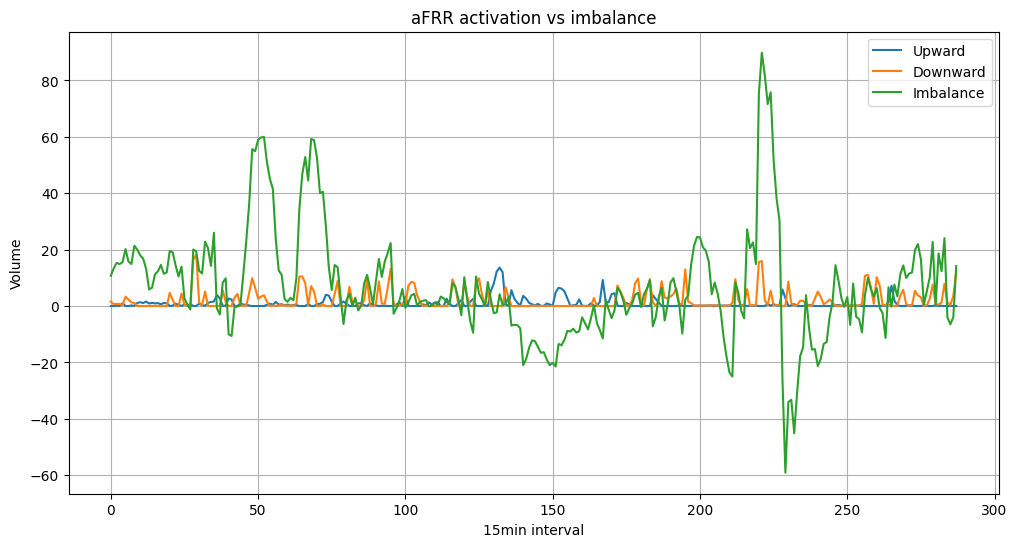

In [34]:
#TASK 1
import pandas as pd
import matplotlib.pyplot as plt

afrr=pd.read_csv("afrr.csv", sep=";")
imb=pd.read_csv("imbalance.csv",sep=";")

afrr["Upward"]=afrr["Upward"].str.replace(",", ".")
afrr["Upward"]=pd.to_numeric(afrr["Upward"])
afrr["Downward"]=afrr["Downward"].str.replace(",", ".")
afrr["Downward"]=pd.to_numeric(afrr["Downward"])
imb["Unnamed: 3"]=imb["Unnamed: 3"].str.replace(",", ".")
imb["Unnamed: 3"]=pd.to_numeric(imb["Unnamed: 3"])                                                            

afrr["aFRR_total"] = afrr["Upward"] + afrr["Downward"]
print("Additional metrics")
print("Total aFRR activation:",afrr["aFRR_total"].sum())
print("Total imbalance:", imb["Unnamed: 3"].abs().sum())
coverage=(afrr["aFRR_total"].sum()/imb["Unnamed: 3"].abs().sum())
print("Coverage ratio:", coverage)

plt.figure(figsize=(12,6))

plt.plot(afrr["Upward"], label="Upward")
plt.plot(afrr["Downward"], label="Downward")
plt.plot(imb["Unnamed: 3"], label="Imbalance")

plt.legend()
plt.grid()
plt.title("aFRR activation vs imbalance")
plt.xlabel("15min interval")
plt.ylabel("Volume")

plt.show()

In [33]:
#TASK 2
import xml.etree.ElementTree as ET

tree = ET.parse("20210325T1530Z_1D_NL_EQ_001_2026.xml")
root = tree.getroot()

#for elem in root.iter():
    #print(elem.tag)

#TOTAL CAPACITY
total_capacity=0.0

for elem in root.iter():
    if 'RotatingMachine.ratedS'in elem.tag:
        try:
            total_capacity+=float(elem.text)
        except:
            pass
print('Total generator capacity(MW): ', total_capacity)

#RATED VOLTAGES
target_id='_2184f365-8cd5-4b5d-8a28-9d68603bb6a4'
print('Rated volatges of transformer NL_TR2_2:')

for end in root.iter():
    for child in end:
        for v in child.attrib.values():
            if target_id in v:
                for sub in end:
                    if 'ratedU'in sub.tag:
                        print('ratedU:',sub.text)

#PATL, TATL
print('Limits for NL-Line_5:')

capture=False

for elem in root.iter():
    if elem.text and 'NL-Line_5'in elem.text:
        capture=True

    if capture and 'CurrentLimit'in elem.tag:
        name=None
        value=None
        for child in elem:
            if 'IdentifiedObject.name'in child.tag:
                name=child.text
            if 'normalValue'in child.tag:
                value=child.text
            if name and value:
                print(name,value)

    if elem.text and 'NL-Line_5'in elem.text and 'NL-Line_5'not in elem.text:
        capture=False

#SLACK GENERATOR
print('Slack generator:')

for rc in root.iter():
    if 'RegulatingControl'in rc.tag:
        name=None
        mode=None
        terminal=None
        
        for child in rc:
            if 'IdentifiedObject.name'in child.tag:
                name=child.text

            if 'RegulatingControl.mode'in child.tag:
                mode=child.attrib.get('{http://www.w3.org/1999/02/22-rdf-syntax-ns#}resource')

            if 'RegulatingControl.Terminal'in child.tag:
                terminal=child.attrib.get('{http://www.w3.org/1999/02/22-rdf-syntax-ns#}resource')

        if mode and 'voltage'in mode:
            print('Slack generator name: ', name)
            print('Slack mode: ', mode)
            print('Slack terminal: ', terminal)

#MISTAKES
#Semantic
print('Semantic error: terminals without equipment')

for term in root.iter():
    if 'Terminal'in term.tag:
        equip=None
        for child in term:
            if 'Terminal.ConductingEquipment'in child.tag:
                equip=child.attrib.get('{http://www.w3.org/1999/02/22-rdf-syntax-ns#}resource')
        if equip is None:
            print('Terminal without equipment:', term.attrib)
            break

#Power system related
print('Power system error: unrealistic limits')

for limit in root.iter():
    if 'CurrentLimit'in limit.tag:
        for child in limit:
            if 'normalValue'in child.tag:
                try:
                    value=float(child.text)
                    if value>10000:
                        print('Unrealistic limit:', value)
                        raise SystemExit
                except:
                    pass

Total generator capacity(MW):  1600.0
Rated volatges of transformer NL_TR2_2:
ratedU: 220
ratedU: 220
ratedU: 220
ratedU: 15.75
Limits for NL-Line_5:
PATL 1876
PATL 1876
TATL 500
TATL 500
PATL 1876
PATL 1876
TATL 500
TATL 500
PATL 1371
PATL 1371
TATL 500
TATL 500
PATL 1371
PATL 1371
TATL 500
TATL 500
PATL 1574
PATL 1574
TATL 500
TATL 500
PATL 1574
PATL 1574
TATL 500
TATL 500
PATL 1233.9
PATL 1233.9
TATL 500
TATL 500
PATL 1233.9
PATL 1233.9
TATL 500
TATL 500
PATL 2000
PATL 2000
TATL 500
TATL 500
PATL 2000
PATL 2000
TATL 500
TATL 500
PATL 3306.644
PATL 3306.644
PATL 46188.04
PATL 46188.04
PATL 839.7826
PATL 839.7826
PATL 461.8804
PATL 461.8804
PATL 46188.04
PATL 46188.04
PATL 3306.644
PATL 3306.644
Slack generator:
Slack generator name:  NL-S1
Slack mode:  http://iec.ch/TC57/CIM100#RegulatingControlModeKind.voltage
Slack terminal:  #_757d4f50-707b-47a0-891c-cbaefd649631
Slack generator name:  NL-G1
Slack mode:  http://iec.ch/TC57/CIM100#RegulatingControlModeKind.voltage
Slack terminal:  